# Vectors and Matrices
## Cohort 8
### Prepared by Kenechi Dukor (modified by Tejumade Afonja)

Import Libraries

In [ ]:
# !pip install numpy
!pip install plotly
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from ipywidgets import interact
import ipywidgets as widgets
from IPython.display import display
# %matplotlib notebook

### Helper Functions

In [ ]:
## PLOT VECTORS
def plot_vectors(vectors, colors=None):
    """
    Plot vectors given a list of vectors.

    Parameters:
    - vectors: List of vectors to be plotted.
    - colors: List of colors for each vector. If None, a default color will be used.
    """

    plt.figure(figsize=(8, 8))

    # If no colors are provided, use a default 'blue' color for all vectors
    if colors is None:
        colors = ['b'] * len(vectors)

    for i, vec in enumerate(vectors):
        plt.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1, color=colors[i], label=f'vector {i+1} {vec}')

    # Setting the limits based on the vectors provided
    max_val = max([max(np.abs(vec)) for vec in vectors])
    plt.xlim(-max_val-1, max_val+1)
    plt.ylim(-max_val-1, max_val+1)

    plt.axvline(x=0, color='grey', lw=1)
    plt.axhline(y=0, color='grey', lw=1)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Vector Plot")
    plt.grid(True)
    plt.legend()
    plt.show()

## TEST
# vectors = [np.array([2, 3]), np.array([-3, 2]), np.array([-2, -1])]
# colors = ['r', 'b', 'g']
# plot_vectors(vectors, colors)

In [ ]:
def plot_vectors_3d(vectors, colors=None):
    """
    Plot 3D vectors given a list of vectors.

    Parameters:
    - vectors: List of 3D vectors to be plotted.
    - colors: List of colors for each vector. If None, a default color will be used.
    """

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # If no colors are provided, use a default 'blue' color for all vectors
    if colors is None:
        colors = ['b'] * len(vectors)

    for i, vec in enumerate(vectors):
        ax.quiver(0, 0, 0, vec[0], vec[1], vec[2], color=colors[i], label=f'vector {i+1} {vec}')

    # Setting the limits based on the vectors provided
    max_val = max([max(np.abs(vec)) for vec in vectors])
    ax.set_xlim([-max_val-1, max_val+1])
    ax.set_ylim([-max_val-1, max_val+1])
    ax.set_zlim([-max_val-1, max_val+1])

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title("3D Vector Plot")
    ax.grid(True)
    ax.legend()
    plt.show()

# ## TEST
# vectors_3d = [np.array([2, 3, 4]), np.array([-3, 2, 1]), np.array([-2, -1, 3])]
# colors = ['r', 'b', 'g']
# plot_vectors_3d(vectors_3d, colors)

In [ ]:
def plot_vectors_3d_interactive(vectors, colors=None):
    """
    Interactive 3D vector plot using Plotly.

    Parameters:
    - vectors: List of 3D vectors
    - colors: List of colors
    """

    if colors is None:
        colors = ['blue'] * len(vectors)

    fig = go.Figure()

    for i, vec in enumerate(vectors):
        fig.add_trace(go.Scatter3d(
            x=[0, vec[0]],
            y=[0, vec[1]],
            z=[0, vec[2]],
            mode='lines+markers',
            marker=dict(size=4),
            line=dict(width=6, color=colors[i]),
            name=f'vector {i+1} {vec}'
        ))

    # Axis limits
    max_val = max([max(np.abs(vec)) for vec in vectors]) + 1

    fig.update_layout(
        scene=dict(
            xaxis=dict(range=[-max_val, max_val], title='X'),
            yaxis=dict(range=[-max_val, max_val], title='Y'),
            zaxis=dict(range=[-max_val, max_val], title='Z')
        ),
        title="Interactive 3D Vector Plot"
    )

    fig.show()

In [ ]:
def plot_vectors_3d_plotly(vectors, colors=None):
    """
    Plot 3D vectors using Plotly.

    Parameters:
    - vectors: List of 3D vectors to be plotted.
    - colors: List of colors for each vector. If None, a default color will be used.
    """

    # If no colors are provided, use a default 'blue' color for all vectors
    if colors is None:
        colors = ['blue'] * len(vectors)

    # Create a trace for each vector
    traces = []
    for i, vec in enumerate(vectors):
        trace = go.Scatter3d(
            x=[0, vec[0]],
            y=[0, vec[1]],
            z=[0, vec[2]],
            mode='lines',
            line=dict(color=colors[i], width=10),
            name=f"Vector {i+1}"
        )
        traces.append(trace)

    # Layout settings
    layout = go.Layout(
        title="3D Vector Plot",
        scene=dict(
            xaxis=dict(nticks=10, range=[-5,5]),
            yaxis=dict(nticks=10, range=[-5,5]),
            zaxis=dict(nticks=10, range=[-5,5]),
            aspectratio=dict(x=1, y=1, z=1)
        )
    )

    fig = go.Figure(data=traces, layout=layout)
    fig.show()

# vectors_3d = [np.array([2, 3, 4]), np.array([-3, 2, 1]), np.array([-2, -1, 3])]
# colors = ['red', 'blue', 'green']
# plot_vectors_3d_plotly(vectors_3d, colors)

In [ ]:
def plot_matrix_3d(matrix):
    x, y = np.meshgrid(np.arange(matrix.shape[1]), np.arange(matrix.shape[0]))

    trace = go.Surface(z=matrix, colorscale='Viridis')
    layout = go.Layout(
        scene=dict(
            xaxis=dict(title='X-axis'),
            yaxis=dict(title='Y-axis'),
            zaxis=dict(title='Value')
        ),
        title='Interactive 3D Plot of Matrix'
    )

    fig = go.Figure(data=[trace], layout=layout)
    fig.show()

# Create an interactive widget for the matrix
matrix_widget = widgets.Textarea(
    value='1 2 3\n4 5 6\n7 8 9',
    description='Enter Matrix:',
    disabled=False
)

## Vectors

**Creating Vectors**

In [ ]:
# Creating a row vector
row_vector = np.array([1, 2, 3])
print("Row Vector:\n\t", row_vector)

# Creating a column vector
col_vector = np.array([[1], [2], [3]])
print("Column Vector:\n", col_vector)

Row Vector:
	 [1 2 3]
Column Vector:
 [[1]
 [2]
 [3]]


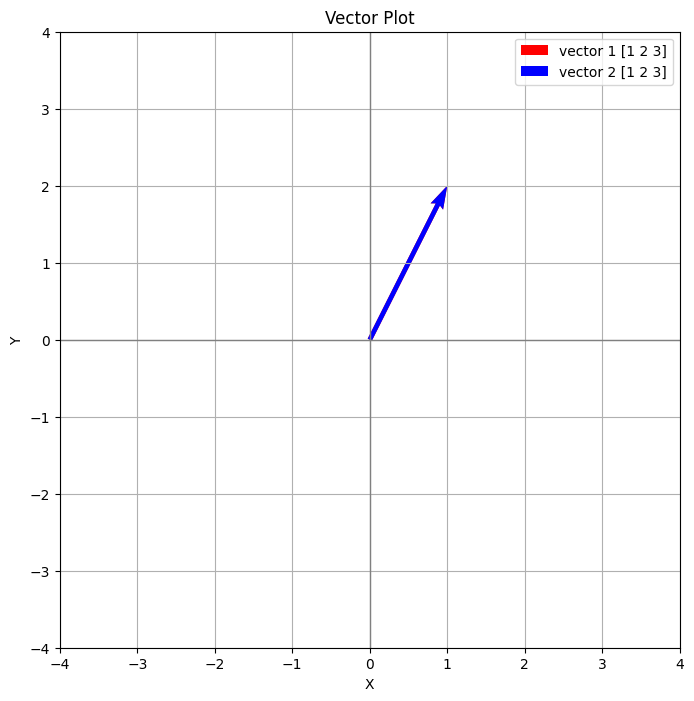

In [ ]:
# TODO: Plot the two vectors. What is the difference?
v1 = np.array([1, 2, 3])
v2 = np.array([1, 2, 3])

vectors = [v1, v2]
colors = ['r', 'b']
plot_vectors(vectors, colors)

### Operations

#### Additions

In [ ]:
v1 = np.array([2, 1, 3])
v2 = np.array([0, 1, 4])

print("v1 is", v1)
print("v2 is", v2)
print("---")

# Addition
v3 = v1 + v2
print("v1 + v2 is", v3)

# Subtraction
v4 = v1 - v2
print("v1 - v2 is", v4)

v1 is [2 1 3]
v2 is [0 1 4]
---
v1 + v2 is [2 2 7]
v1 - v2 is [ 2  0 -1]


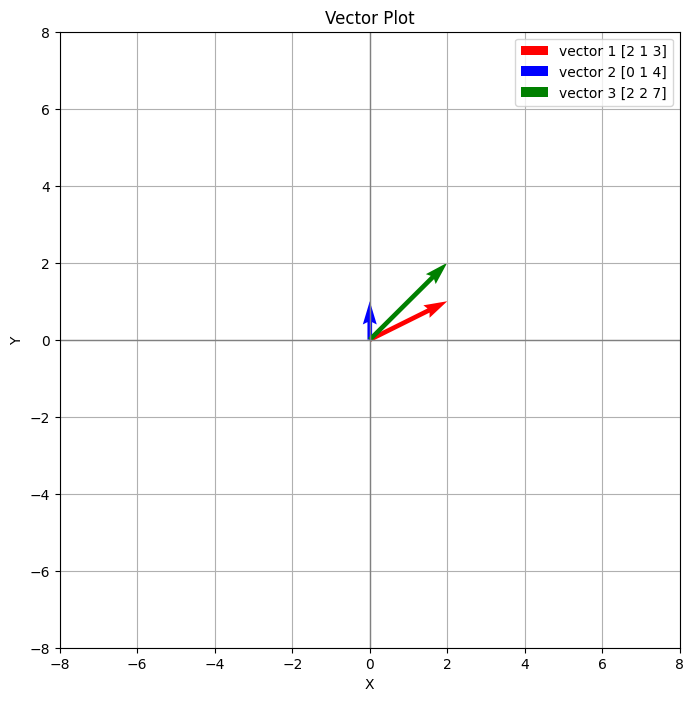

In [ ]:
# TODO: Plot the v1, v2 and the result of the summation in a plot
vectors = [v1, v2, v3]
colors = ['r', 'b', 'g']
plot_vectors(vectors, colors)

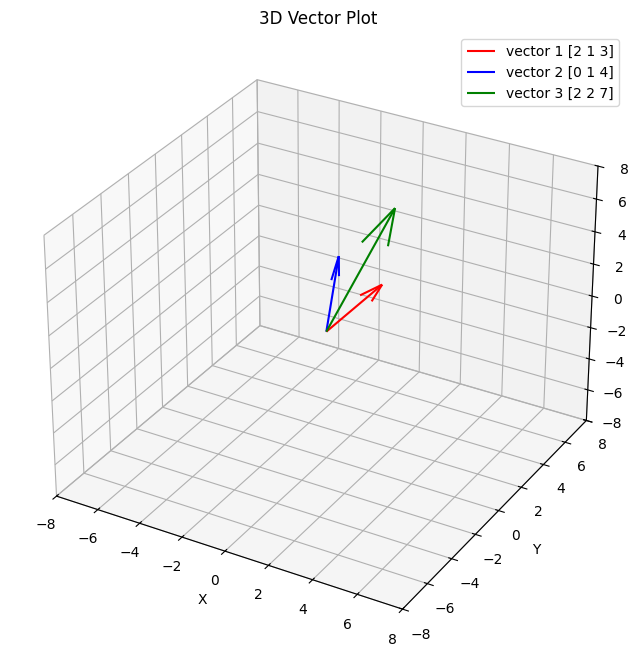

In [ ]:
# TODO: Recreate plots in 3D
plot_vectors_3d(vectors, colors)

In [ ]:
vectors

[array([2, 1, 3]), array([0, 1, 4]), array([2, 2, 7])]

In [ ]:
vectors_3d = [np.array([2, 3, 4]), np.array([-3, 2, 1]), np.array([-2, -1, 3])]
colors = ['red', 'blue', 'green']

plot_vectors_3d_interactive(vectors_3d, colors)

#### Subtraction

In [ ]:
# TODO:

#### Scaling

In [ ]:
# TODO: What happens if we scale one of the vector by a factor of 2? What do you notice? What is 2 called?


### Dot Product

In [ ]:
v1 = np.array([2, 1, 3])
v2 = np.array([0, 1, 4])

v3 = np.dot(v1, v2)

print(v3)

13


In [ ]:
print((v1[0] * v2[0]) + (v1[1] * v2[1]) + (v1[2] * v2[2]) )

13


## Matrices

#### Basics

In [ ]:
matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])

print("Matrix:\n", matrix)
# plot_matrix_3d(matrix)

Matrix:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]


In [ ]:
matrix.shape


(3, 3)

### Operations

#### Addition and Subtraction

In [ ]:
A = np.array([[1, 2, 3], [4, 5, 6]])

print("Matrix A:\n", A, end="\n\n")


B = np.array([[7, 8], [9, 10], [11, 12]])
print("Matrix B:\n", B)

Matrix A:
 [[1 2 3]
 [4 5 6]]

Matrix B:
 [[ 7  8]
 [ 9 10]
 [11 12]]


In [ ]:
# TODO: Add matrix A and B

# TODO: Subtract matrix A and B

In [ ]:
_A = np.array([[1, 2, 3], [4, 5, 6]])
_B = np.array([[7, 8, 9], [9, 10, 11]])

In [ ]:
# TODO: Add matrix A and B

# TODO: Subtract matrix A and B

#### Dot Product


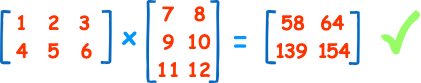

In [ ]:
A = np.array([[1, 2, 3], [4, 5, 6]])


print("Matrix A:\n", A, end="\n\n")


B = np.array([[7, 8], [9, 10], [11, 12]])


print("Matrix B:\n", B, end="\n\n")

Matrix A:
 [[1 2 3]
 [4 5 6]]

Matrix B:
 [[ 7  8]
 [ 9 10]
 [11 12]]



In [ ]:
# TODO: Perform a matrix multiplication. Hint: numpy func -> np.dot(A, B) or check numpy documentation
np.dot(A,B)

array([[ 58,  64],
       [139, 154]])

In [ ]:
# Transpose

print("Matrix A:\n", A, end="\n\n")

print("Matrix A transpose:\n", A.T)

Matrix A:
 [[1 2 3]
 [4 5 6]]

Matrix A transpose:
 [[1 4]
 [2 5]
 [3 6]]


In [ ]:
A = np.array([[7, 8], [9, 10], [11, 12]])

print("Matrix A:\n", A, end="\n\n")


B = np.array([[1, 2, 3], [4, 5, 6], [13, 14, 15]])
print("Matrix B:\n", B, end="\n\n")

Matrix A:
 [[ 7  8]
 [ 9 10]
 [11 12]]

Matrix B:
 [[ 1  2  3]
 [ 4  5  6]
 [13 14 15]]



In [ ]:
# TODO: Perform a matrix multiplication. Hint: transpose -> B.T, or check numpy documentation

#### Calculating Determinant and Inverse

In [ ]:
A = np.array([[7, 8], [9, 10], [11, 12]])

In [ ]:
# TODO: Use np.linalg.inv(A) to calculate the inverse

In [ ]:
# TODO: Use np.linalg.det(A) to calculate the determinant

#### Solving Simultaneous Equations

In [ ]:
# TODO:
# 2x + 3y = 12
# 4x - 2y = 10

## Sparse Matrix

In [ ]:
from scipy.sparse import csr_matrix, csc_matrix

In [ ]:
# Define the matrix
matrix = np.array([
    [0, 1, 0, 2],
    [1, 0, 3, 0],
    [0, 0, 0, 0],
    [4, 0, 5, 0]
])

In [ ]:
# Convert to CSR format
matrix_csr = csr_matrix(matrix)
print("CSR Values:", matrix_csr.data)
print("CSR Column Indices:", matrix_csr.indices)
print("CSR Row Pointers:", matrix_csr.indptr)

In [ ]:
# TODO: Find the reverse. Hint: pass your array into  -> csr_matrix((data, indices, indptr)). Convert output to array.

In [ ]:
# Convert to CSC format
matrix_csc = csc_matrix(matrix)
print("\nCSC Values:", matrix_csc.data)
print("CSC Row Indices:", matrix_csc.indices)
print("CSC Column Pointers:", matrix_csc.indptr)

In [ ]:
# TODO: Find the reverse.

## Lets Play with a Picture of Ladi Kwali

In [ ]:
!pip install Pillow

In [ ]:
!wget "https://thedesignedit.com/wp-content/uploads/2022/01/612-body-vessel-clay-2022-1.jpg"

In [ ]:
import base64
from io import BytesIO
from PIL import Image
# Load the image
image_path = '/content/612-body-vessel-clay-2022-1.jpg'

image = Image.open(image_path)
image_array = np.array(image)

print(type(image_array))  # Should print <class 'numpy.ndarray'>
print(image_array.shape)

### Display Image

In [ ]:
plt.imshow(image_array)
plt.axis('off')  # To turn off axis numbers
plt.show()

In [ ]:
gray_image = image_array.mean(axis=-1)
plt.imshow(gray_image, cmap='gray')
plt.axis('off')  # To turn off axis numbers
plt.show()

In [ ]:
# TODO: Play around with the image array and show us your result. Try multiplying scalars first.


In [ ]:
bright = image_array + 50
bright = np.clip(bright, 0, 255)
plt.imshow(bright)
plt.axis('off')  # To turn off axis numbers
plt.show()

In [ ]:
negative = 255 - image_array
plt.imshow(negative)

In [ ]:
import pandas as pd

# Set a seed for reproducibility
np.random.seed(42)

# Generate the actuarial data matrix
actuarial_data = np.random.randint(1, 1001, size=(150, 7))

# Convert to DataFrame with meaningful headers
headers = ["Age", "Policy_Amount", "Premium", "Claims", "Expenses", "Profit", "Duration"]
df = pd.DataFrame(actuarial_data, columns=headers)

print(df)

In [ ]:
# Define a risk factor for each column
risk_factors = np.array([1.5, 0.5, 1.0, 1.2, 0.8, 0.7, 0.6])

In [ ]:
# TODO: Calculate the risk score. Hint: Use dot product